# AeroNet Lite — full demo

Runs **CSP repair**, **fleet GA**, **A*** delivery routing, and shows **two figures**.

The import cell clears cached `src.*` modules so Jupyter always loads your latest `visualization.py` and `main.py`. If anything still looks wrong, use **Kernel → Restart** and run all cells.

In [3]:
%matplotlib inline


 AERONET LAYOUT VALIDATION 

  R1 FAILED - Industrial not adjacent to School/Hospital
    R1 FAILED: Industrial cell (7, 2) adjacent to Hospital at (7, 3)
    R1 FAILED: Industrial cell (8, 3) adjacent to Hospital at (7, 3)
    R1 FAILED: Industrial cell (9, 1) adjacent to School at (8, 1)
  R2 PASSED - Residential within 3 cells of a hub
  R3 PASSED - Hub within 2 cells of a charging pad
  R4 PASSED - Hospital has medical pickup within 1 cell

Layout validity = FALSE  (3 violation(s) total)

 AERONET LAYOUT VALIDATION 

  R1 PASSED - Industrial not adjacent to School/Hospital
  R2 PASSED - Residential within 3 cells of a hub
  R3 PASSED - Hub within 2 cells of a charging pad
  R4 PASSED - Hospital has medical pickup within 1 cell

Layout validity = TRUE - all CSP constraints satisfied.

Fleet (GA)
  Light: 0  Heavy: 8
  Cost: $14400  (budget used: 96.0%)
  Payload: 40 kg  |  Coverage (vs reachable demand): 100.0%
  Score: 51.00

 DELIVERY ASSIGNMENT TABLE
Job   Drone  Type    Hub    

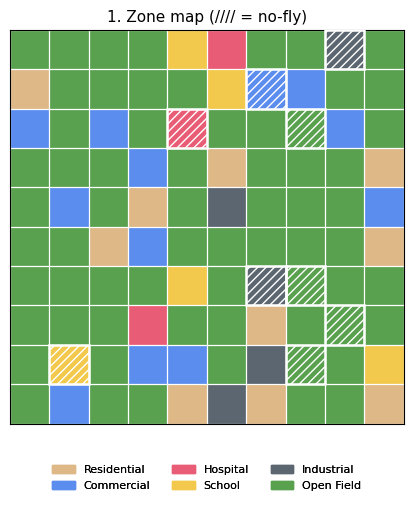

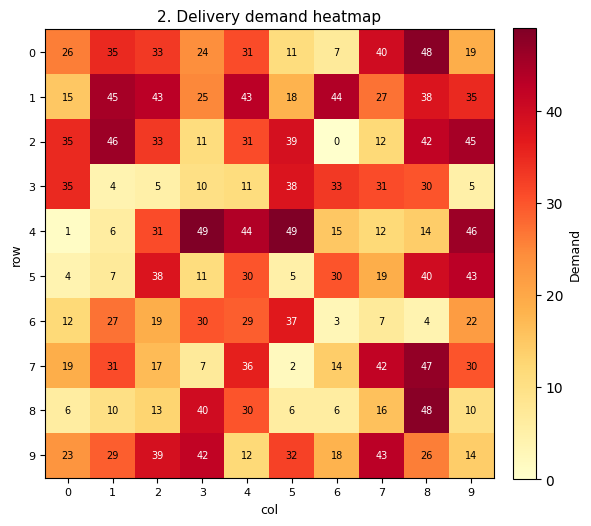

[Route] J1 assigned to D1 (Heavy, range=20 cells)
  hub -> pickup: cost=5.60  [(0, 1), (1, 1), (2, 1), (2, 2), (3, 2), (3, 3), (4, 3)]
  pickup -> drop-off: cost=5.40  [(4, 3), (3, 3), (2, 3), (2, 2), (2, 1), (2, 0), (1, 0)]
  drop-off -> hub: cost=2.00  [(1, 0), (0, 0), (0, 1)]


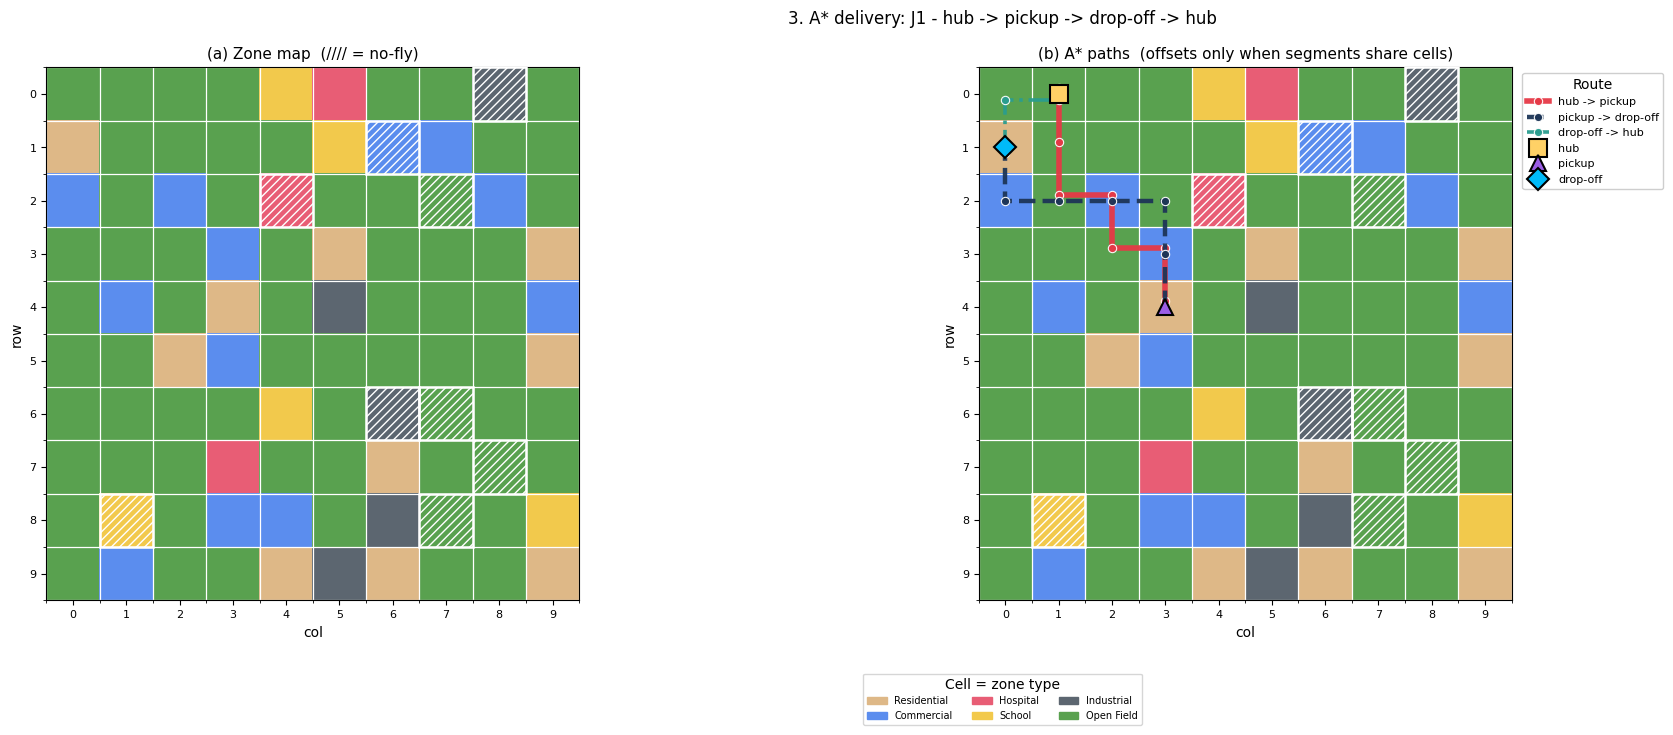


 PHASE 4 - DISRUPTION & REROUTING
  Drone : D1 (Heavy, range=20 cells)
  Status: in flight - arrived at pickup (4, 3)
  Next  : drop-off (1, 0)  ->  hub (0, 1)

  Original remaining path:
    pickup -> drop-off: 6 steps
    drop-off -> hub: 2 steps

Step 11: no-fly cell activated at (2, 2).
  D1 (J1): route crosses (2, 2) - rerouting from (4, 3).
  D1 rerouted using A*. Rerouted successfully (8 steps remaining).

  Updated remaining path:
    pickup -> drop-off: 6 steps
    drop-off -> hub: 2 steps


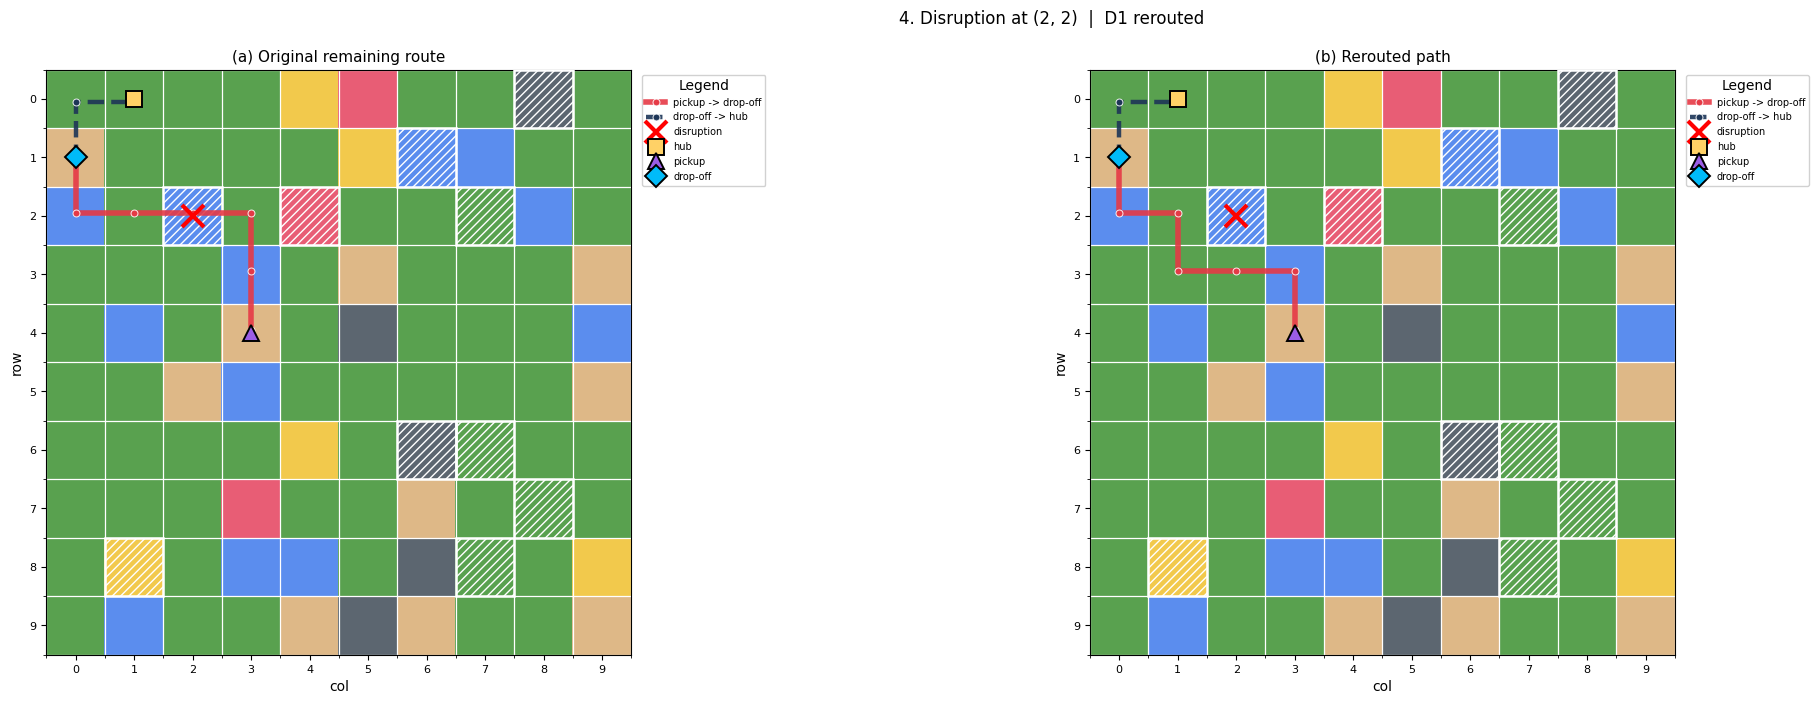

In [4]:
from pathlib import Path
import sys
import time

def project_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "src" / "main.py").is_file():
            return d
    return here


root = project_root()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

# Jupyter caches old src.* modules; reload(main) does not refresh dependencies.
# Drop them so visualization (and everything else) loads from disk.
for key in list(sys.modules.keys()):
    if key == "src" or key.startswith("src."):
        del sys.modules[key]

from src.main import run_full_demo

grid = run_full_demo(seed=time.time())